In [1]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd, pingouin as pg
from scipy.io import loadmat
from pprint import pprint
from scipy.signal import butter, filtfilt
from scipy.stats import linregress
from scipy.stats import pearsonr


# Extraction function
def get_epoch(channel, trial, file):
    start = file['datastart'][channel-1, trial] - 1
    end = file['dataend'][channel-1, trial]
    return file['data'][0][int(start):int(end)]

def rms(signal):
    return np.sqrt(np.mean(signal**2))



PROCESSING: Hanif
Trials detected: 4
Detected 11 marker pulses
Detected missing baseline-start marker


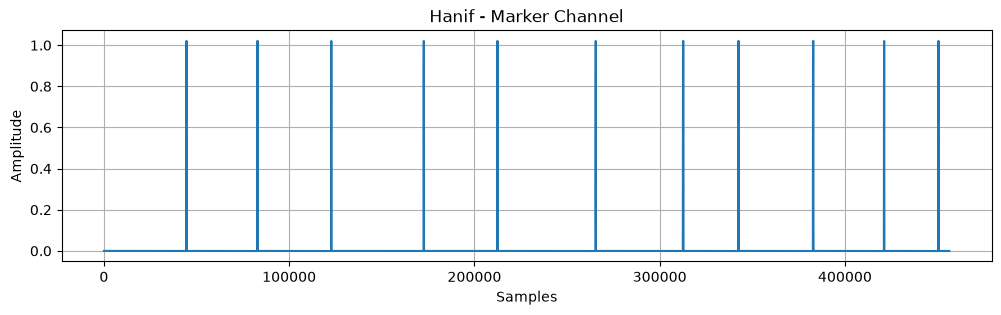


=== Segment Durations ===
baseline_1  : 44.47 sec
arm_up      : 38.27 sec
1kg_up      : 39.87 sec
2kg_up      : 49.94 sec
3kg_up      : 39.73 sec
4kg         : 53.03 sec
3kg_down    : 47.18 sec
2kg_down    : 29.89 sec
1kg_down    : 40.31 sec
arm_down    : 38.33 sec
baseline_2  : 29.31 sec

=== RMS Validation ===

baseline_1   | Biceps Full = 0.000005 | Biceps Window Mean = 0.000005
arm_up       | Biceps Full = 0.000031 | Biceps Window Mean = 0.000030
1kg_up       | Biceps Full = 0.000056 | Biceps Window Mean = 0.000056
2kg_up       | Biceps Full = 0.000110 | Biceps Window Mean = 0.000109
3kg_up       | Biceps Full = 0.000171 | Biceps Window Mean = 0.000170
4kg          | Biceps Full = 0.000263 | Biceps Window Mean = 0.000262
3kg_down     | Biceps Full = 0.000161 | Biceps Window Mean = 0.000159
2kg_down     | Biceps Full = 0.000108 | Biceps Window Mean = 0.000105
1kg_down     | Biceps Full = 0.000086 | Biceps Window Mean = 0.000085
arm_down     | Biceps Full = 0.000042 | Biceps Window 

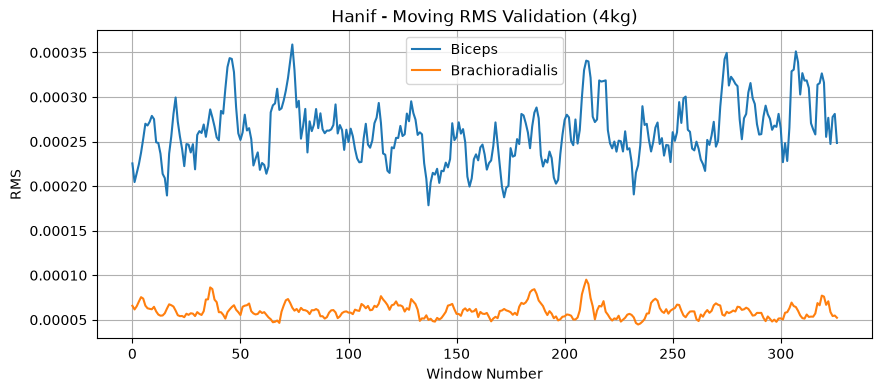


PROCESSING: Bharghav
Trials detected: 1
Detected 12 marker pulses
Detected standard 12-pulse protocol


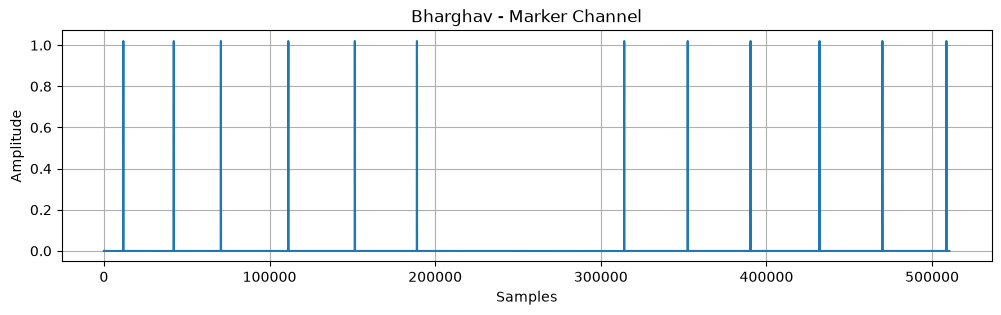


=== Segment Durations ===
baseline_1  : 30.44 sec
arm_up      : 28.43 sec
1kg_up      : 40.74 sec
2kg_up      : 40.14 sec
3kg_up      : 37.50 sec
4kg         : 125.12 sec
3kg_down    : 38.34 sec
2kg_down    : 37.94 sec
1kg_down    : 41.64 sec
arm_down    : 37.96 sec
baseline_2  : 38.64 sec

=== RMS Validation ===

baseline_1   | Biceps Full = 0.000004 | Biceps Window Mean = 0.000004
arm_up       | Biceps Full = 0.000013 | Biceps Window Mean = 0.000013
1kg_up       | Biceps Full = 0.000037 | Biceps Window Mean = 0.000037
2kg_up       | Biceps Full = 0.000060 | Biceps Window Mean = 0.000059
3kg_up       | Biceps Full = 0.000091 | Biceps Window Mean = 0.000090
4kg          | Biceps Full = 0.000132 | Biceps Window Mean = 0.000131
3kg_down     | Biceps Full = 0.000100 | Biceps Window Mean = 0.000099
2kg_down     | Biceps Full = 0.000046 | Biceps Window Mean = 0.000045
1kg_down     | Biceps Full = 0.000042 | Biceps Window Mean = 0.000041
arm_down     | Biceps Full = 0.000018 | Biceps Window

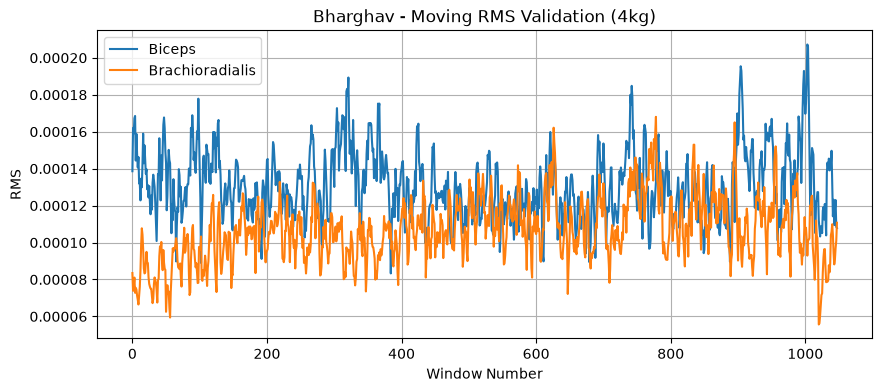


PROCESSING: Sam
Trials detected: 1
Detected 12 marker pulses
Detected standard 12-pulse protocol


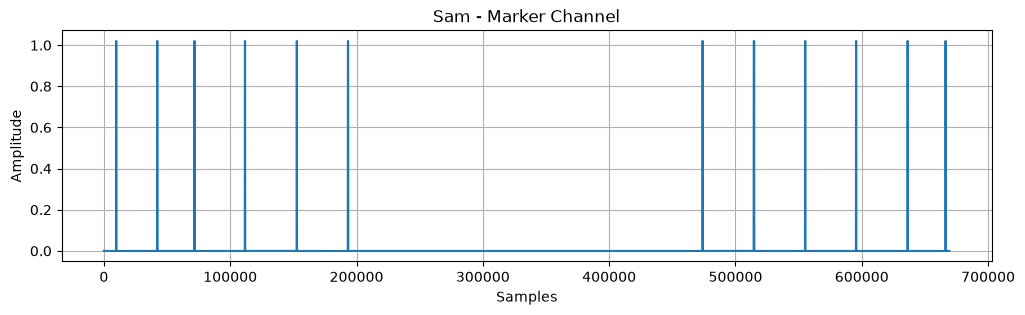


=== Segment Durations ===
baseline_1  : 32.45 sec
arm_up      : 29.55 sec
1kg_up      : 39.92 sec
2kg_up      : 41.02 sec
3kg_up      : 40.52 sec
4kg         : 280.68 sec
3kg_down    : 40.62 sec
2kg_down    : 40.66 sec
1kg_down    : 40.34 sec
arm_down    : 40.79 sec
baseline_2  : 30.02 sec

=== RMS Validation ===

baseline_1   | Biceps Full = 0.000018 | Biceps Window Mean = 0.000018
arm_up       | Biceps Full = 0.000023 | Biceps Window Mean = 0.000023
1kg_up       | Biceps Full = 0.000026 | Biceps Window Mean = 0.000026
2kg_up       | Biceps Full = 0.000043 | Biceps Window Mean = 0.000042
3kg_up       | Biceps Full = 0.000058 | Biceps Window Mean = 0.000057
4kg          | Biceps Full = 0.000107 | Biceps Window Mean = 0.000105
3kg_down     | Biceps Full = 0.000102 | Biceps Window Mean = 0.000100
2kg_down     | Biceps Full = 0.000073 | Biceps Window Mean = 0.000072
1kg_down     | Biceps Full = 0.000043 | Biceps Window Mean = 0.000043
arm_down     | Biceps Full = 0.000026 | Biceps Window

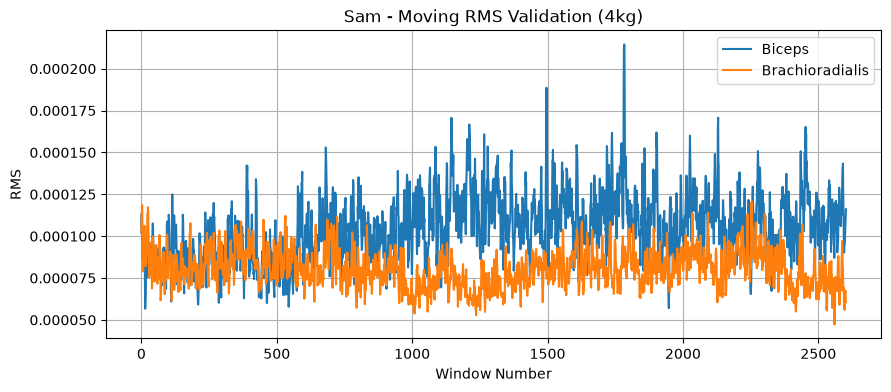

In [2]:
# =============================================================================
# DEBUGGING BLOCK
# Marker Detection, Segmentation and Moving RMS Validation
# =============================================================================

subjects = ["Hanif", "Bharghav", "Sam"]

for subject in subjects:

    print("\n" + "="*80)
    print(f"PROCESSING: {subject}")
    print("="*80)

    # -------------------------------------------------------------------------
    # Load data
    # -------------------------------------------------------------------------

    mat = loadmat(f"{subject}_Exp_2.mat")

    Fs = int(mat["samplerate"][0][0])

    n_trials = mat['datastart'].shape[1]

    print(f"Trials detected: {n_trials}")

    # Concatenate all trials automatically
    biceps = np.concatenate([
        get_epoch(5, t, mat).flatten()
        for t in range(n_trials)
    ])

    brachio = np.concatenate([
        get_epoch(6, t, mat).flatten()
        for t in range(n_trials)
    ])

    marker = np.concatenate([
        get_epoch(2, t, mat).flatten()
        for t in range(n_trials)
    ])

    # -------------------------------------------------------------------------
    # Marker Detection
    # -------------------------------------------------------------------------

    threshold = 1

    edges = np.where(
        np.diff((marker > threshold).astype(int)) == 1
    )[0]

    print(f"Detected {len(edges)} marker pulses")

    # -------------------------------------------------------------------------
    # Segment Definitions
    # -------------------------------------------------------------------------

    if len(edges) == 12:

        print("Detected standard 12-pulse protocol")

        segments = {
            "baseline_1": (edges[0], edges[1]),
            "arm_up":     (edges[1], edges[2]),
            "1kg_up":     (edges[2], edges[3]),
            "2kg_up":     (edges[3], edges[4]),
            "3kg_up":     (edges[4], edges[5]),
            "4kg":        (edges[5], edges[6]),
            "3kg_down":   (edges[6], edges[7]),
            "2kg_down":   (edges[7], edges[8]),
            "1kg_down":   (edges[8], edges[9]),
            "arm_down":   (edges[9], edges[10]),
            "baseline_2": (edges[10], edges[11]),
        }

    elif len(edges) == 11:

        print("Detected missing baseline-start marker")

        segments = {
            "baseline_1": (0, edges[0]),
            "arm_up":     (edges[0], edges[1]),
            "1kg_up":     (edges[1], edges[2]),
            "2kg_up":     (edges[2], edges[3]),
            "3kg_up":     (edges[3], edges[4]),
            "4kg":        (edges[4], edges[5]),
            "3kg_down":   (edges[5], edges[6]),
            "2kg_down":   (edges[6], edges[7]),
            "1kg_down":   (edges[7], edges[8]),
            "arm_down":   (edges[8], edges[9]),
            "baseline_2": (edges[9], edges[10]),
        }

    else:

        raise ValueError(
            f"{subject}: Unexpected number of pulses ({len(edges)})"
        )

    # -------------------------------------------------------------------------
    # Marker Plot
    # -------------------------------------------------------------------------

    plt.figure(figsize=(12,3))
    plt.plot(marker)
    plt.title(f"{subject} - Marker Channel")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

    # -------------------------------------------------------------------------
    # Segment Durations
    # -------------------------------------------------------------------------

    print("\n=== Segment Durations ===")

    for name, (start, end) in segments.items():

        duration = (end - start) / Fs

        print(
            f"{name:12s}: "
            f"{duration:.2f} sec"
        )

    # -------------------------------------------------------------------------
    # Moving RMS Validation
    # -------------------------------------------------------------------------

    trim = 10 * Fs

    window_size = int(0.4 * Fs)
    step        = int(0.1 * Fs)
    debug_results = {}

    for name, (start, end) in segments.items():

        start += trim
        end -= trim

        if end <= start:
            print(f"Skipping {name}")
            continue

        biceps_seg = biceps[start:end]
        brachio_seg = brachio[start:end]

        biceps_windows = []
        brachio_windows = []

        for i in range(
            0,
            len(biceps_seg) - window_size + 1,
            step
        ):

            biceps_windows.append(
                np.sqrt(
                    np.mean(
                        biceps_seg[i:i+window_size]**2
                    )
                )
            )

            brachio_windows.append(
                np.sqrt(
                    np.mean(
                        brachio_seg[i:i+window_size]**2
                    )
                )
            )

        biceps_windows = np.array(biceps_windows)
        brachio_windows = np.array(brachio_windows)

        debug_results[name] = {

            "full_rms_biceps":
                np.sqrt(np.mean(biceps_seg**2)),

            "full_rms_brachio":
                np.sqrt(np.mean(brachio_seg**2)),

            "mean_window_rms_biceps":
                np.mean(biceps_windows),

            "mean_window_rms_brachio":
                np.mean(brachio_windows),

            "biceps_windows":
                biceps_windows,

            "brachio_windows":
                brachio_windows
        }

    # -------------------------------------------------------------------------
    # RMS Validation
    # -------------------------------------------------------------------------

    print("\n=== RMS Validation ===\n")

    for name in debug_results:

        print(
            f"{name:12s} | "
            f"Biceps Full = {debug_results[name]['full_rms_biceps']:.6f} | "
            f"Biceps Window Mean = {debug_results[name]['mean_window_rms_biceps']:.6f}"
        )

    # -------------------------------------------------------------------------
    # Example Plot
    # -------------------------------------------------------------------------

    seg_name = "4kg"

    plt.figure(figsize=(10,4))

    plt.plot(
        debug_results[seg_name]["biceps_windows"],
        label="Biceps"
    )

    plt.plot(
        debug_results[seg_name]["brachio_windows"],
        label="Brachioradialis"
    )

    plt.title(
        f"{subject} - Moving RMS Validation ({seg_name})"
    )

    plt.xlabel("Window Number")
    plt.ylabel("RMS")
    plt.grid(True)
    plt.legend()

    plt.show()


Processing Hanif
Detected 11 pulses

Processing Bharghav
Detected 12 pulses

Processing Sam
Detected 12 pulses

Raw RMS Dataset
  Participant Condition           Muscle       RMS
0       Hanif    arm_up           Biceps  0.000031
1       Hanif    arm_up  Brachioradialis  0.000017
2       Hanif    1kg_up           Biceps  0.000058
3       Hanif    1kg_up  Brachioradialis  0.000021
4       Hanif    2kg_up           Biceps  0.000110

=== Combined RMS Summary ===
  Load           Muscle  Mean_RMS    SD_RMS
0  1kg           Biceps  0.000049  0.000020
1  1kg  Brachioradialis  0.000025  0.000008
2  2kg           Biceps  0.000074  0.000029
3  2kg  Brachioradialis  0.000044  0.000015
4  3kg           Biceps  0.000114  0.000048
5  3kg  Brachioradialis  0.000061  0.000019
6  4kg           Biceps  0.000171  0.000086
7  4kg  Brachioradialis  0.000083  0.000023
8  arm           Biceps  0.000025  0.000010
9  arm  Brachioradialis  0.000019  0.000006


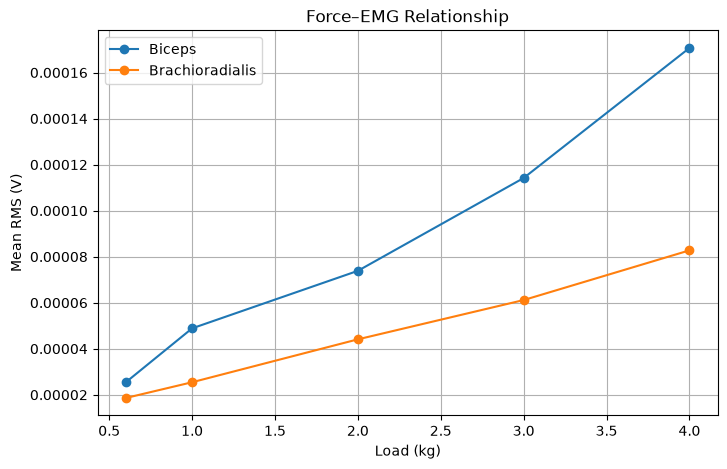


=== COMBINED ANOVA ===
          Source            SS  ddof1  ddof2            MS          F  \
0           Load  4.181222e-08      4      8  1.045306e-08  28.059834   
1         Muscle  1.211387e-08      1      2  1.211387e-08   2.003905   
2  Load * Muscle  5.920081e-09      4      8  1.480020e-09   2.105757   

      p_unc  p_GG_corr       ng2       eps  
0  0.000093   0.030871  0.631107  0.260928  
1  0.292549   0.292549  0.331398  1.000000  
2  0.171816   0.283137  0.194996  0.253376  


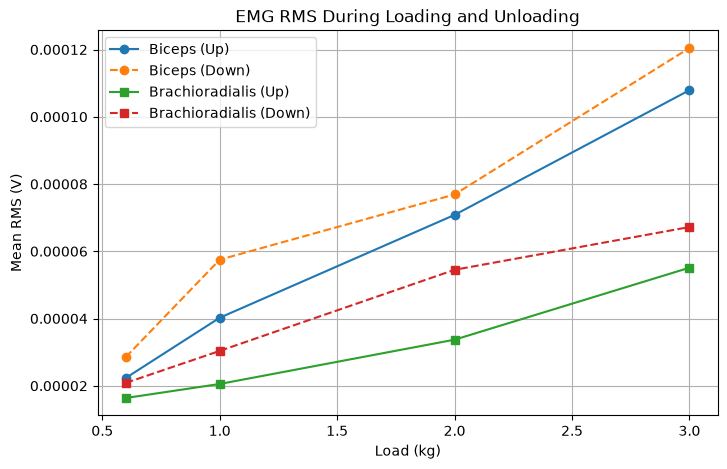


=== UP vs DOWN SUMMARY ===
   Load Direction           Muscle  Mean_RMS    SD_RMS
0   1kg      Down           Biceps  0.000058  0.000025
1   1kg      Down  Brachioradialis  0.000030  0.000011
2   1kg        Up           Biceps  0.000040  0.000016
3   1kg        Up  Brachioradialis  0.000021  0.000005
4   2kg      Down           Biceps  0.000077  0.000026
5   2kg      Down  Brachioradialis  0.000054  0.000023
6   2kg        Up           Biceps  0.000071  0.000035
7   2kg        Up  Brachioradialis  0.000034  0.000007
8   3kg      Down           Biceps  0.000120  0.000037
9   3kg      Down  Brachioradialis  0.000067  0.000024
10  3kg        Up           Biceps  0.000108  0.000060
11  3kg        Up  Brachioradialis  0.000055  0.000015
12  arm      Down           Biceps  0.000029  0.000012
13  arm      Down  Brachioradialis  0.000021  0.000006
14  arm        Up           Biceps  0.000022  0.000009
15  arm        Up  Brachioradialis  0.000016  0.000006

=== Biceps ===
             Source  

In [5]:
# =============================================================================
# EXPERIMENT 2 - RMS ANALYSIS
# Force–EMG Relationship
# =============================================================================

subjects = ["Hanif", "Bharghav", "Sam"]

TRIM_SECONDS = 5
MARKER_THRESHOLD = 1

LOAD_ORDER = ["arm", "1kg", "2kg", "3kg", "4kg"]

all_rows = []

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_segments(edges):

    if len(edges) == 12:

        return {
            "arm_up":   (edges[1], edges[2]),
            "1kg_up":   (edges[2], edges[3]),
            "2kg_up":   (edges[3], edges[4]),
            "3kg_up":   (edges[4], edges[5]),
            "4kg":      (edges[5], edges[6]),
            "3kg_down": (edges[6], edges[7]),
            "2kg_down": (edges[7], edges[8]),
            "1kg_down": (edges[8], edges[9]),
            "arm_down": (edges[9], edges[10]),
        }

    elif len(edges) == 11:

        return {
            "arm_up":   (edges[0], edges[1]),
            "1kg_up":   (edges[1], edges[2]),
            "2kg_up":   (edges[2], edges[3]),
            "3kg_up":   (edges[3], edges[4]),
            "4kg":      (edges[4], edges[5]),
            "3kg_down": (edges[5], edges[6]),
            "2kg_down": (edges[6], edges[7]),
            "1kg_down": (edges[7], edges[8]),
            "arm_down": (edges[8], edges[9]),
        }

    else:

        raise ValueError(
            f"Unexpected pulse count ({len(edges)})"
        )

# =============================================================================
# EXTRACT RMS VALUES
# =============================================================================

for participant in subjects:

    print(f"\nProcessing {participant}")

    mat = loadmat(f"{participant}_Exp_2.mat")

    Fs = int(mat["samplerate"][0][0])

    trim = TRIM_SECONDS * Fs

    n_trials = mat["datastart"].shape[1]

    # -------------------------------------------------------------------------
    # Rebuild continuous signals
    # -------------------------------------------------------------------------

    biceps = np.concatenate([
        get_epoch(5, t, mat).flatten()
        for t in range(n_trials)
    ])

    brachio = np.concatenate([
        get_epoch(6, t, mat).flatten()
        for t in range(n_trials)
    ])

    marker = np.concatenate([
        get_epoch(2, t, mat).flatten()
        for t in range(n_trials)
    ])

    # -------------------------------------------------------------------------
    # Marker detection
    # -------------------------------------------------------------------------

    edges = np.where(
        np.diff(
            (marker > MARKER_THRESHOLD).astype(int)
        ) == 1
    )[0]

    print(f"Detected {len(edges)} pulses")

    segments = get_segments(edges)

    # -------------------------------------------------------------------------
    # RMS extraction
    # -------------------------------------------------------------------------

    for condition, (start, end) in segments.items():

        start += trim
        end -= trim

        if end <= start:
            continue

        biceps_seg = biceps[start:end]
        brachio_seg = brachio[start:end]

        all_rows.extend([
            {
                "Participant": participant,
                "Condition": condition,
                "Muscle": "Biceps",
                "RMS": rms(biceps_seg)
            },
            {
                "Participant": participant,
                "Condition": condition,
                "Muscle": "Brachioradialis",
                "RMS": rms(brachio_seg)
            }
        ])

# =============================================================================
# BUILD DATAFRAME
# =============================================================================

df = pd.DataFrame(all_rows)

print("\nRaw RMS Dataset")
print(df.head())

# =============================================================================
# COMBINED LOAD ANALYSIS
# Average Up + Down Conditions
# =============================================================================

combined_df = df.copy()

combined_df["Load"] = (
    combined_df["Condition"]
    .str.replace("_up", "", regex=False)
    .str.replace("_down", "", regex=False)
)

combined_df = (
    combined_df
    .groupby(
        ["Participant", "Muscle", "Load"],
        as_index=False
    )["RMS"]
    .mean()
)

# -----------------------------------------------------------------------------
# Summary table
# -----------------------------------------------------------------------------

combined_summary = (
    combined_df
    .groupby(["Load", "Muscle"])
    .agg(
        Mean_RMS=("RMS", "mean"),
        SD_RMS=("RMS", "std")
    )
    .reset_index()
)

print("\n=== Combined RMS Summary ===")
print(combined_summary)

# -----------------------------------------------------------------------------
# Force–EMG plot
# -----------------------------------------------------------------------------

plot_table = (
    combined_df
    .groupby(["Load", "Muscle"])
    ["RMS"]
    .mean()
    .reset_index()
)

biceps_plot = (
    plot_table
    .query("Muscle == 'Biceps'")
    .set_index("Load")
    .loc[LOAD_ORDER]["RMS"]
)

brachio_plot = (
    plot_table
    .query("Muscle == 'Brachioradialis'")
    .set_index("Load")
    .loc[LOAD_ORDER]["RMS"]
)

loads = [0.6, 1, 2, 3, 4]

plt.figure(figsize=(8,5))

plt.plot(
    loads,
    biceps_plot,
    marker="o",
    label="Biceps"
)

plt.plot(
    loads,
    brachio_plot,
    marker="o",
    label="Brachioradialis"
)

plt.xlabel("Load (kg)")
plt.ylabel("Mean RMS (V)")
plt.title("Force–EMG Relationship")
plt.grid(True)
plt.legend()

plt.show()

# -----------------------------------------------------------------------------
# Repeated-measures ANOVA
# -----------------------------------------------------------------------------

anova_combined = pg.rm_anova(
    data=combined_df,
    dv="RMS",
    within=["Load", "Muscle"],
    subject="Participant",
    detailed=True
)

print("\n=== COMBINED ANOVA ===")
print(anova_combined)

# =============================================================================
# UP vs DOWN ANALYSIS
# =============================================================================

direction_df = (
    df[df["Condition"] != "4kg"]
    .copy()
)

direction_df["Direction"] = np.where(
    direction_df["Condition"].str.contains("_down"),
    "Down",
    "Up"
)

direction_df["Load"] = (
    direction_df["Condition"]
    .str.replace("_up", "", regex=False)
    .str.replace("_down", "", regex=False)
)

# =============================================================================
# UP vs DOWN PLOT
# =============================================================================

plot_order = ["arm", "1kg", "2kg", "3kg"]

plot_table = (
    direction_df
    .groupby(["Load", "Direction", "Muscle"])
    ["RMS"]
    .mean()
    .reset_index()
)

# Biceps
biceps_up = (
    plot_table[
        (plot_table["Muscle"] == "Biceps") &
        (plot_table["Direction"] == "Up")
    ]
    .set_index("Load")
    .loc[plot_order]["RMS"]
)

biceps_down = (
    plot_table[
        (plot_table["Muscle"] == "Biceps") &
        (plot_table["Direction"] == "Down")
    ]
    .set_index("Load")
    .loc[plot_order]["RMS"]
)

# Brachioradialis
brachio_up = (
    plot_table[
        (plot_table["Muscle"] == "Brachioradialis") &
        (plot_table["Direction"] == "Up")
    ]
    .set_index("Load")
    .loc[plot_order]["RMS"]
)

brachio_down = (
    plot_table[
        (plot_table["Muscle"] == "Brachioradialis") &
        (plot_table["Direction"] == "Down")
    ]
    .set_index("Load")
    .loc[plot_order]["RMS"]
)

loads = [0.6, 1, 2, 3]

plt.figure(figsize=(8,5))

plt.plot(
    loads,
    biceps_up,
    marker="o",
    label="Biceps (Up)"
)

plt.plot(
    loads,
    biceps_down,
    marker="o",
    linestyle="--",
    label="Biceps (Down)"
)

plt.plot(
    loads,
    brachio_up,
    marker="s",
    label="Brachioradialis (Up)"
)

plt.plot(
    loads,
    brachio_down,
    marker="s",
    linestyle="--",
    label="Brachioradialis (Down)"
)

plt.xlabel("Load (kg)")
plt.ylabel("Mean RMS (V)")
plt.title("EMG RMS During Loading and Unloading")
plt.grid(True)
plt.legend()

plt.show()

# -----------------------------------------------------------------------------
# Summary table
# -----------------------------------------------------------------------------

direction_summary = (
    direction_df
    .groupby(
        ["Load", "Direction", "Muscle"]
    )
    .agg(
        Mean_RMS=("RMS", "mean"),
        SD_RMS=("RMS", "std")
    )
    .reset_index()
)

print("\n=== UP vs DOWN SUMMARY ===")
print(direction_summary)

# -----------------------------------------------------------------------------
# Direction ANOVA
# -----------------------------------------------------------------------------

for muscle in ["Biceps", "Brachioradialis"]:

    print(f"\n=== {muscle} ===")

    temp = direction_df[
        direction_df["Muscle"] == muscle
    ]

    anova_direction = pg.rm_anova(
        data=temp,
        dv="RMS",
        within=["Load", "Direction"],
        subject="Participant",
        detailed=True
    )

    print(anova_direction)

# =============================================================================
# SAVE OUTPUTS
# =============================================================================

combined_df.to_csv(
    "Exp2_RMS_Combined_Loads.csv",
    index=False
)

direction_df.to_csv(
    "Exp2_RMS_Direction.csv",
    index=False
)

print("\nSaved:")
print(" - Exp2_RMS_Combined_Loads.csv")
print(" - Exp2_RMS_Direction.csv")


Processing Hanif
Hanif: 43.0 sec fatigue segment


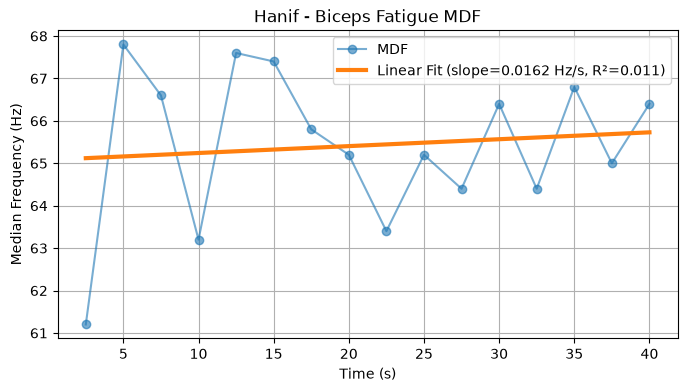

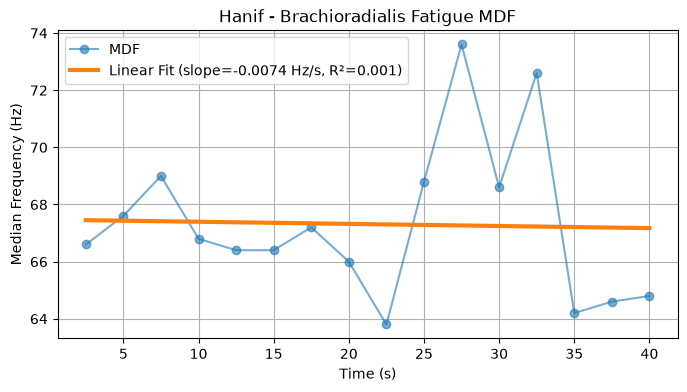


Processing Bharghav
Bharghav: 115.1 sec fatigue segment


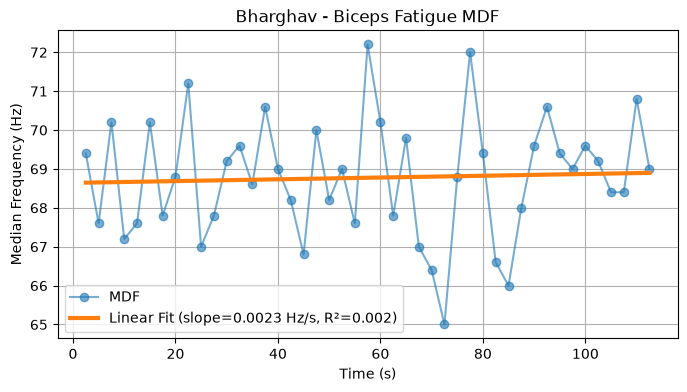

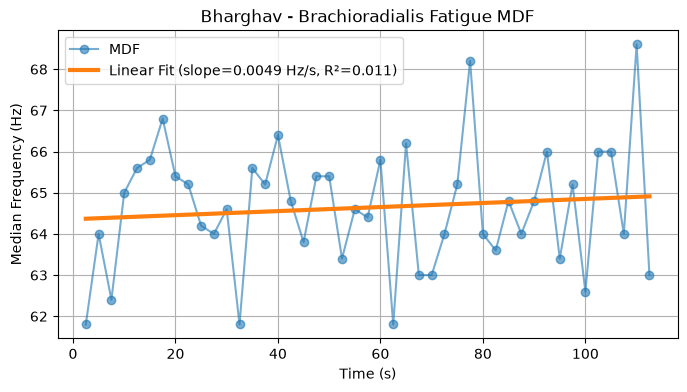


Processing Sam
Sam: 270.7 sec fatigue segment


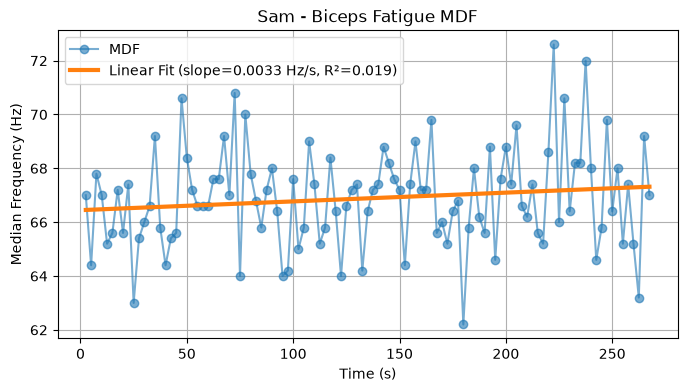

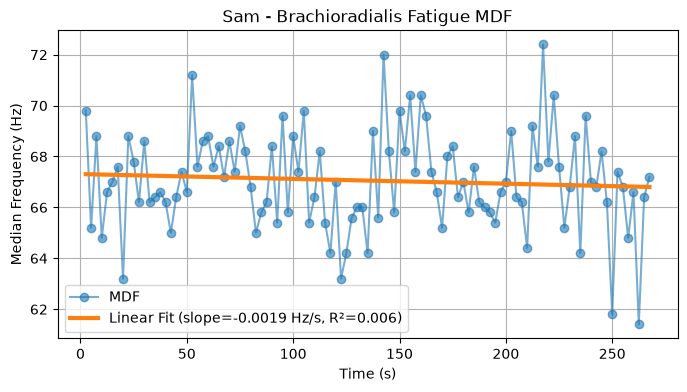


=== FATIGUE SUMMARY ===
  Participant           Muscle  MDF_Start  MDF_End  Delta_MDF  Slope_Hz_per_s  \
0       Hanif           Biceps       61.2     66.4        5.2        0.016235   
1       Hanif  Brachioradialis       66.6     64.8       -1.8       -0.007412   
2    Bharghav           Biceps       69.4     69.0       -0.4        0.002287   
3    Bharghav  Brachioradialis       61.8     63.0        1.2        0.004933   
4         Sam           Biceps       67.0     67.0        0.0        0.003252   
5         Sam  Brachioradialis       69.8     67.2       -2.6       -0.001890   

   R_squared  
0   0.011461  
1   0.001023  
2   0.002369  
3   0.011446  
4   0.018597  
5   0.005771  


In [13]:
    from scipy.signal import butter, filtfilt, welch

    # =============================================================================
    # FATIGUE ANALYSIS (4 kg SEGMENT ONLY)
    # =============================================================================

    subjects = ["Hanif", "Bharghav", "Sam"]

    fatigue_summary = []

    # =============================================================================
    # Helper
    # =============================================================================

    def bandpass(signal, fs, low=20, high=450, order=4):

        nyq = fs / 2

        b, a = butter(
            order,
            [low/nyq, high/nyq],
            btype="band"
        )

        return filtfilt(b, a, signal)

    # =============================================================================
    # Analysis
    # =============================================================================

    for participant in subjects:

        print(f"\nProcessing {participant}")

        mat = loadmat(f"{participant}_Exp_2.mat")

        Fs = int(mat["samplerate"][0][0])

        n_trials = mat["datastart"].shape[1]

        # -------------------------------------------------------------------------
        # Rebuild signals
        # -------------------------------------------------------------------------

        biceps = np.concatenate([
            get_epoch(5, t, mat).flatten()
            for t in range(n_trials)
        ])

        brachio = np.concatenate([
            get_epoch(6, t, mat).flatten()
            for t in range(n_trials)
        ])

        marker = np.concatenate([
            get_epoch(2, t, mat).flatten()
            for t in range(n_trials)
        ])

        # -------------------------------------------------------------------------
        # Filter
        # -------------------------------------------------------------------------

        biceps = bandpass(biceps, Fs)
        brachio = bandpass(brachio, Fs)

        # -------------------------------------------------------------------------
        # Marker detection
        # -------------------------------------------------------------------------

        edges = np.where(
            np.diff((marker > 1).astype(int)) == 1
        )[0]

        # -------------------------------------------------------------------------
        # Extract 4 kg segment
        # -------------------------------------------------------------------------

        if len(edges) == 12:

            fatigue_start = edges[5]
            fatigue_end   = edges[6]

        elif len(edges) == 11:

            fatigue_start = edges[4]
            fatigue_end   = edges[5]

        else:

            raise ValueError(
                f"{participant}: Unexpected pulse count ({len(edges)})"
            )

        # Optional: trim transition periods

        trim = 5 * Fs

        fatigue_start += trim
        fatigue_end   -= trim

        # -------------------------------------------------------------------------
        # Fatigue Duration
        # -------------------------------------------------------------------------

        duration_sec = (fatigue_end - fatigue_start) / Fs

        print(
            f"{participant}: "
            f"{duration_sec:.1f} sec fatigue segment"
        )

        biceps_fatigue = biceps[fatigue_start:fatigue_end]
        brachio_fatigue = brachio[fatigue_start:fatigue_end]

        # -------------------------------------------------------------------------
        # MDF calculation function
        # -------------------------------------------------------------------------



        def moving_mdf(signal):

            window_sec = 5
            overlap_sec = 2.5

            window_size = int(window_sec * Fs)
            step = int((window_sec - overlap_sec) * Fs)

            mdf_values = []
            time_axis = []

            for start in range(
                0,
                len(signal) - window_size + 1,
                step
            ):

                segment = signal[start:start + window_size]

                f, Pxx = welch(
                    segment,
                    fs=Fs,
                    nperseg=window_size
                )

                cumulative_power = np.cumsum(Pxx)

                idx = np.where(
                    cumulative_power >= cumulative_power[-1] / 2
                )[0][0]

                mdf_values.append(f[idx])

                time_axis.append(
                    (start + window_size/2) / Fs
                )

            return (
                np.array(time_axis),
                np.array(mdf_values)
            )

        # -------------------------------------------------------------------------
        # Both muscles
        # -------------------------------------------------------------------------

        for muscle_name, signal in {

            "Biceps": biceps_fatigue,
            "Brachioradialis": brachio_fatigue

        }.items():

            time_axis, mdf_values = moving_mdf(signal)

            slope, intercept, r, p, stderr = linregress(
                time_axis,
                mdf_values
            )
            fit_line = intercept + slope * time_axis
            r_squared = r**2

            fatigue_summary.append({

                "Participant": participant,
                "Muscle": muscle_name,

                "MDF_Start": mdf_values[0],
                "MDF_End": mdf_values[-1],
                "Delta_MDF": mdf_values[-1] - mdf_values[0],
                "Slope_Hz_per_s": slope,
                "R_squared": r_squared

            })

            # ---------------------------------------------------------------------
            # Plot
            # ---------------------------------------------------------------------

            plt.figure(figsize=(8,4))

            plt.plot(
                time_axis,
                mdf_values,
                marker='o',
                alpha=0.6,
                label='MDF'
            )

            plt.plot(
                time_axis,
                fit_line,
                linewidth=3,
                label=(
                    f'Linear Fit '
                    f'(slope={slope:.4f} Hz/s, '
                    f'R²={r_squared:.3f})'
                )
            )

            plt.xlabel("Time (s)")
            plt.ylabel("Median Frequency (Hz)")
            plt.title(
                f"{participant} - {muscle_name} Fatigue MDF"
            )

            plt.grid(True)
            plt.legend()

            plt.show()


    # =============================================================================
    # Summary Table
    # =============================================================================

    fatigue_df = pd.DataFrame(fatigue_summary)

    print("\n=== FATIGUE SUMMARY ===")
    print(fatigue_df)